In [ ]:
# Install if needed
!pip install torch torchvision grad-cam opencv-python matplotlib scikit-image


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 58.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44285 sha256=07cfb87b0fdb47dda78fc2ae180b29bdc1241434bbdc00ed02efbee2a3948de0
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [1]:
import kagglehub
import shutil
import os
# Download latest version
path = kagglehub.dataset_download("sachinkumar413/covid-pneumonia-normal-chest-xray-images")
print("Path to dataset files:", path)
# Destination directory
destination = "/content/datasets"
# Move the dataset to /content/
if not os.path.exists(destination):
    shutil.copytree(path, destination)
    print(f"Dataset moved to: {destination}")
else:
    print(f"Dataset already exists at: {destination}")

Using Colab cache for faster access to the 'covid-pneumonia-normal-chest-xray-images' dataset.
Path to dataset files: /kaggle/input/covid-pneumonia-normal-chest-xray-images
Dataset moved to: /content/datasets


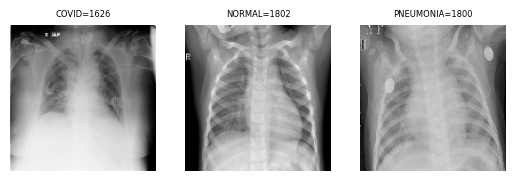

In [2]:
import os
import cv2
import matplotlib.pyplot as plt
def show_one_image_per_folder_with_count(root_dir):
    no=0
    for subdir in sorted(os.listdir(root_dir)):
        no=no+1
        subfolder_path = os.path.join(root_dir, subdir)

        if os.path.isdir(subfolder_path):
            # Get all image files in this subfolder
            image_files = [f for f in os.listdir(subfolder_path)
                           if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff'))]
            image_count = len(image_files)
            if image_count > 0:
                # Read the first image
                first_image_path = os.path.join(subfolder_path, image_files[12])
                image = cv2.imread(first_image_path)
                image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
                image = cv2.resize(image, (128,128))
                plt.subplot(2,3,no)
                # Display using matplotlib
                plt.imshow(image)
                plt.title(f"{subdir}={image_count}",fontsize=6)
                plt.axis('off')
plt.show()
# Example usage
folder_path = "/content/datasets"  # Replace with your dataset path
show_one_image_per_folder_with_count(folder_path)

In [ ]:
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision import models, transforms
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget


# ==========================================================
# Load Image
# ==========================================================
def load_image(image_path, device):
    rgb = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)
    rgb = cv2.resize(rgb, (224, 224))
    rgb_float = rgb.astype(np.float32) / 255.0

    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(
            [0.485, 0.456, 0.406],
            [0.229, 0.224, 0.225]
        )
    ])

    tensor = transform(rgb).unsqueeze(0).to(device)

    return rgb, rgb_float, tensor


# ==========================================================
# FGSM Attack
# ==========================================================
def fgsm_attack(model, image_tensor, epsilon):

    adv = image_tensor.clone().detach().requires_grad_(True)

    output = model(adv)
    target = output.argmax(dim=1)

    loss = torch.nn.CrossEntropyLoss()(output, target)

    model.zero_grad()
    loss.backward()

    adv = adv + epsilon * adv.grad.sign()
    adv = adv.detach()

    return adv
# ==========================================================
# PGD Attack
# ==========================================================
def pgd_attack(model, image_tensor, epsilon=16/255, alpha=2/255, num_iter=20):

    ori = image_tensor.detach()
    adv = ori.clone().detach()

    for _ in range(num_iter):

        adv.requires_grad_(True)

        output = model(adv)
        target = output.argmax(dim=1)

        loss = torch.nn.CrossEntropyLoss()(output, target)

        model.zero_grad()
        loss.backward()

        adv = adv + alpha * adv.grad.sign()

        # Project into epsilon-ball
        eta = torch.clamp(adv - ori, min=-epsilon, max=epsilon)
        adv = ori + eta

        # Keep normalized pixel values in a reasonable range
        adv = torch.clamp(adv, -3.0, 3.0).detach()

    return adv
# ==========================================================
# DeepFool Attack
# ==========================================================
def deepfool_attack(model,
                    image_tensor,
                    num_classes=10,
                    overshoot=0.02,
                    max_iter=50):

    model.eval()

    x = image_tensor.clone().detach().requires_grad_(True)

    with torch.no_grad():
        output = model(x)
    label = output.argmax(dim=1).item()

    adv = x.clone().detach()

    for _ in range(max_iter):

        adv.requires_grad_(True)

        output = model(adv)

        current = output.argmax(dim=1).item()

        if current != label:
            break

        model.zero_grad()

        output[0, label].backward(retain_graph=True)
        grad_orig = adv.grad.detach().clone()

        min_ratio = float("inf")
        best_w = None

        for k in range(min(num_classes, output.shape[1])):

            if k == label:
                continue

            adv.grad.zero_()

            output[0, k].backward(retain_graph=True)

            grad_k = adv.grad.detach().clone()

            w = grad_k - grad_orig
            f = output[0, k] - output[0, label]

            norm_w = torch.norm(w.flatten())

            if norm_w == 0:
                continue

            ratio = torch.abs(f) / norm_w

            if ratio < min_ratio:
                min_ratio = ratio
                best_w = w

        if best_w is None:
            break

        r = (min_ratio + 1e-4) * best_w / torch.norm(best_w.flatten())

        adv = (adv + (1 + overshoot) * r).detach()

    return adv
# ==========================================================
# Tensor to RGB
# ==========================================================
def tensor_to_rgb(tensor):

    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    img = tensor.squeeze().cpu().numpy().transpose(1, 2, 0)
    img = img * std + mean
    img = np.clip(img, 0, 1)

    return img


# ==========================================================
# Compute LPAM + Metrics
# ==========================================================
def compute_lpam(model, image_tensor, rgb_float):

    target_layers = [
        model.layer1[-1],
        model.layer2[-1],
        model.layer3[-1],
        model.layer4[-1]
    ]

    with torch.no_grad():
        pred = model(image_tensor)

    cls = pred.argmax().item()

    cams = []

    for layer in target_layers:

        cam = GradCAM(
            model=model,
            target_layers=[layer]
        )

        grayscale = cam(
            input_tensor=image_tensor,
            targets=[ClassifierOutputTarget(cls)]
        )[0]

        overlay = show_cam_on_image(
            rgb_float,
            grayscale,
            use_rgb=True
        )

        cams.append((grayscale, overlay))

    # ================= LPAM =================

    weights = np.array([np.mean(g) for g, _ in cams])
    weights = weights / (weights.sum() + 1e-8)

    lpam = np.zeros_like(cams[0][0])

    for w, (g, _) in zip(weights, cams):
        lpam += w * g

    lpam = (lpam - lpam.min()) / (lpam.max() - lpam.min() + 1e-8)

    # ================= Metrics =================

    p = lpam / (lpam.sum() + 1e-8)

    entropy = -(p * np.log(p + 1e-8)).sum()

    area = np.sum(lpam > 0.6)
    area_ratio = area / lpam.size

    max_activation = lpam.max()

    concentration = max_activation / (lpam.mean() + 1e-8)

    attack_score = (
        0.4 * (1 / (entropy + 1e-8))
        + 0.3 * concentration
        + 0.3 * (1 - area_ratio)
    )

    metrics = {
        "Entropy": entropy,
        "Activation Area": area,
        "Area Ratio": area_ratio,
        "Maximum Activation": max_activation,
        "Concentration Score": concentration,
        "Attack Score": attack_score
    }

    return cams, lpam, metrics


# ==========================================================
# Print Metrics
# ==========================================================
def print_metrics(title, metrics):

    print(f"\n{'='*50}")
    print(title)
    print("="*50)

    for k, v in metrics.items():
        if isinstance(v, (int, np.integer)):
            print(f"{k:<25}: {v}")
        else:
            print(f"{k:<25}: {v:.6f}")


# ==========================================================
# Visualization
# ==========================================================
def visualize(original,
              processed,
              cams,
              lpam,
              attack_score,
              threshold,
              title):

    lpam_overlay = show_cam_on_image(
        processed,
        lpam,
        use_rgb=True
    )

    fig, axs = plt.subplots(1, 7, figsize=(28, 4))

    axs[0].imshow(original)
    axs[0].set_title("Original")
    axs[0].axis("off")

    axs[1].imshow(processed)
    axs[1].set_title(title)
    axs[1].axis("off")

    for i, (_, overlay) in enumerate(cams):
        axs[i + 2].imshow(overlay)
        axs[i + 2].set_title(f"Layer {i+1}")
        axs[i + 2].axis("off")

    axs[6].imshow(lpam_overlay)

    if attack_score > threshold:
        axs[6].set_title("LPAM\nAdversarial")
    else:
        axs[6].set_title("LPAM\nClean")

    axs[6].axis("off")

    plt.tight_layout()
    plt.show()


Clean Image Metrics
Entropy                  : 10.632690
Activation Area          : 3432
Area Ratio               : 0.068399
Maximum Activation       : 1.000000
Concentration Score      : 3.407415
Attack Score             : 1.339325

Prediction : Clean Image


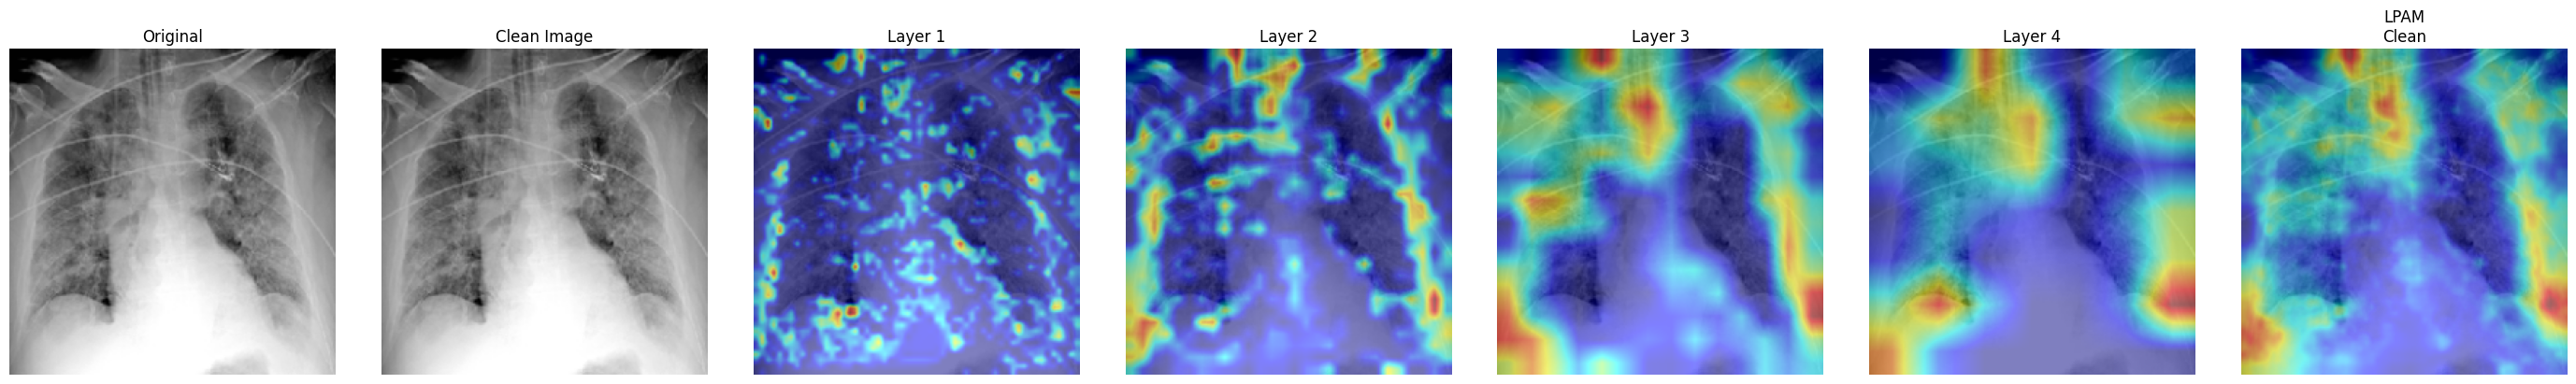

In [ ]:
# ==========================================================
# Settings
# ==========================================================

image_path = "/content/datasets/COVID/COVID_1002.png"

device = "cuda" if torch.cuda.is_available() else "cpu"

epsilon = 8 / 255.0

THRESHOLD = 1.35


# ==========================================================
# Load Pretrained Model
# ==========================================================

model = models.resnet50(
    weights=models.ResNet50_Weights.DEFAULT
)

model.eval()
model.to(device)


# ==========================================================
# Load Image
# ==========================================================

rgb, rgb_float, input_tensor = load_image(
    image_path,
    device
)


# ==========================================================
# CLEAN IMAGE
# ==========================================================

cams, lpam, metrics = compute_lpam(
    model,
    input_tensor,
    rgb_float
)

print_metrics("Clean Image Metrics", metrics)

if metrics["Attack Score"] > THRESHOLD:
    print("\nPrediction : Adversarial Attack Detected")
else:
    print("\nPrediction : Clean Image")

visualize(
    rgb,
    rgb_float,
    cams,
    lpam,
    metrics["Attack Score"],
    THRESHOLD,
    "Clean Image"
)


FGSM Adversarial Image Metrics
Entropy                  : 10.392539
Activation Area          : 2128
Area Ratio               : 0.042411
Maximum Activation       : 1.000000
Concentration Score      : 5.869023
Attack Score             : 2.086473

Prediction : Adversarial Attack Detected


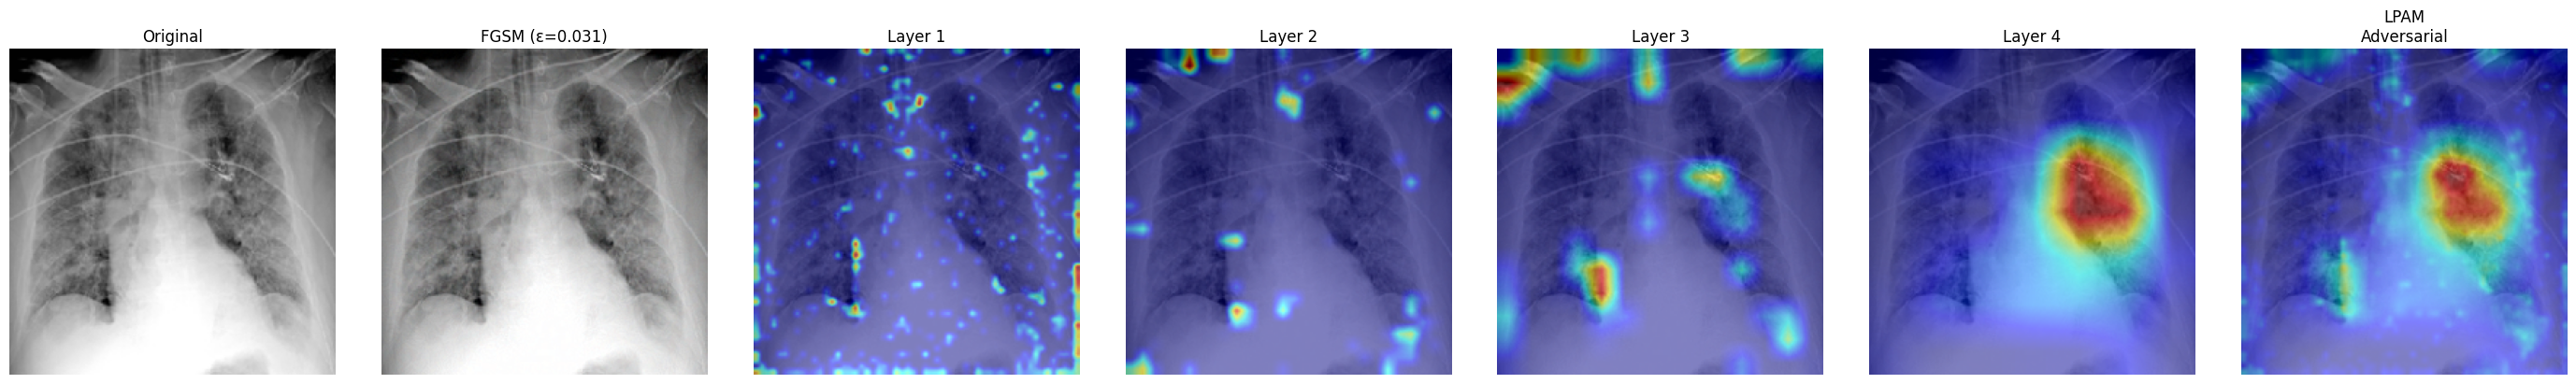

In [ ]:
# ==========================================================
# FGSM ADVERSARIAL IMAGE
# ==========================================================

adv_tensor = fgsm_attack(
    model,
    input_tensor,
    epsilon
)

adv_rgb = tensor_to_rgb(
    adv_tensor
)

cams_adv, lpam_adv, metrics_adv = compute_lpam(
    model,
    adv_tensor,
    adv_rgb
)

print_metrics("FGSM Adversarial Image Metrics", metrics_adv)

if metrics_adv["Attack Score"] > THRESHOLD:
    print("\nPrediction : Adversarial Attack Detected")
else:
    print("\nPrediction : Clean Image")

visualize(
    rgb,
    adv_rgb,
    cams_adv,
    lpam_adv,
    metrics_adv["Attack Score"],
    THRESHOLD,
    f"FGSM (ε={epsilon:.3f})"
)


PGD Adversarial Image Metrics
Entropy                  : 10.677216
Activation Area          : 1475
Area Ratio               : 0.029397
Maximum Activation       : 1.000000
Concentration Score      : 3.431035
Attack Score             : 1.357955

Prediction : Adversarial Attack Detected


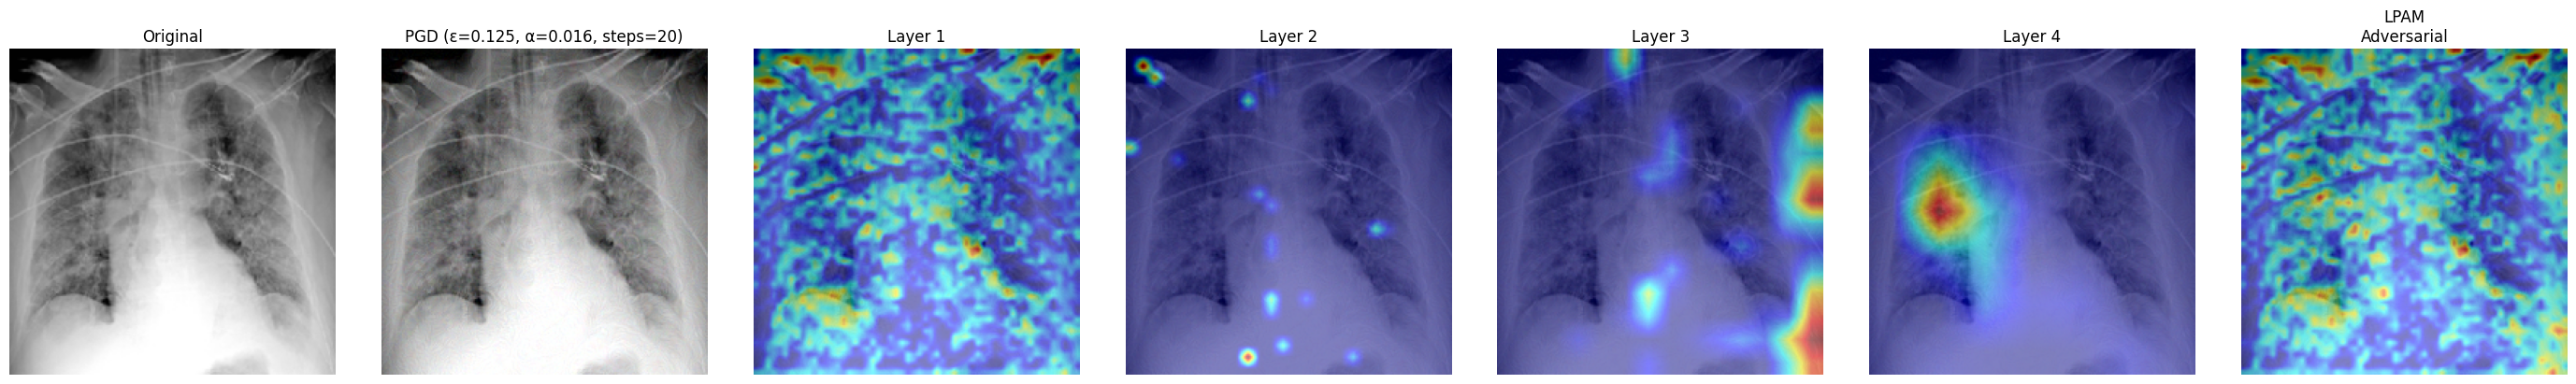

In [ ]:
# ==========================================================
# PGD ADVERSARIAL IMAGE
# ==========================================================

epsilon = 32 / 255
alpha = 4 / 255
num_iter = 20

adv_tensor = pgd_attack(
    model=model,
    image_tensor=input_tensor,
    epsilon=epsilon,
    alpha=alpha,
    num_iter=num_iter
)

adv_rgb = tensor_to_rgb(adv_tensor)

cams_adv, lpam_adv, metrics_adv = compute_lpam(
    model,
    adv_tensor,
    adv_rgb
)

print_metrics("PGD Adversarial Image Metrics", metrics_adv)

if metrics_adv["Attack Score"] > THRESHOLD:
    print("\nPrediction : Adversarial Attack Detected")
else:
    print("\nPrediction : Clean Image")

visualize(
    rgb,
    adv_rgb,
    cams_adv,
    lpam_adv,
    metrics_adv["Attack Score"],
    THRESHOLD,
    f"PGD (ε={epsilon:.3f}, α={alpha:.3f}, steps={num_iter})"
)


DeepFool Adversarial Image Metrics
Entropy                  : 10.306990
Activation Area          : 2496
Area Ratio               : 0.049745
Maximum Activation       : 1.000000
Concentration Score      : 6.232594
Attack Score             : 2.193663

Prediction : Adversarial Attack Detected


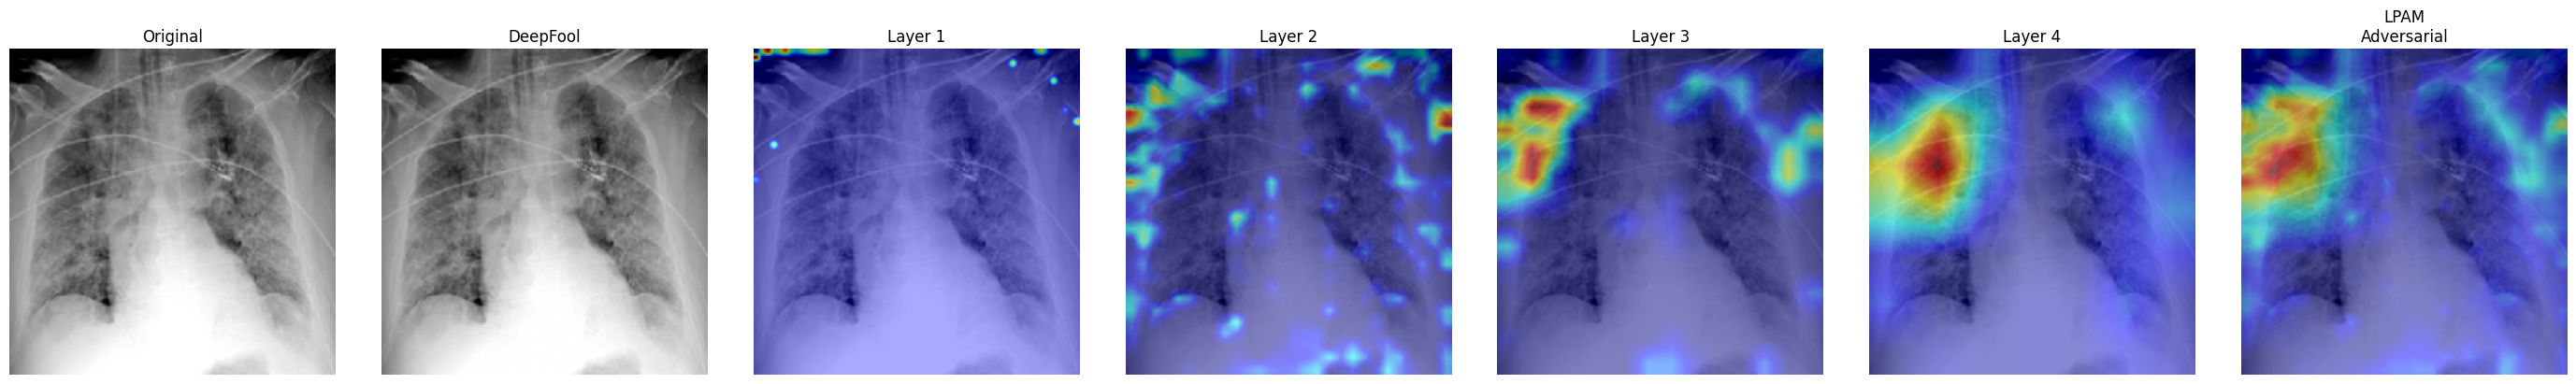

In [ ]:
# ==========================================================
# DEEPFOOL ADVERSARIAL IMAGE
# ==========================================================
adv_tensor = deepfool_attack(
    model=model,
    image_tensor=input_tensor,
    num_classes=10,
    overshoot=0.02,
    max_iter=50
).detach()

adv_rgb = tensor_to_rgb(adv_tensor)

cams_adv, lpam_adv, metrics_adv = compute_lpam(
    model,
    adv_tensor,
    adv_rgb
)

print_metrics("DeepFool Adversarial Image Metrics", metrics_adv)

if metrics_adv["Attack Score"] > THRESHOLD:
    print("\nPrediction : Adversarial Attack Detected")
else:
    print("\nPrediction : Clean Image")

visualize(
    rgb,
    adv_rgb,
    cams_adv,
    lpam_adv,
    metrics_adv["Attack Score"],
    THRESHOLD,
    "DeepFool"
)